# GenSec: MePTCDI on graphene

GenSec is a quasi-random structure search code for molecules on fixed frames. The typical use case is: keep a surface, slab, or other frame fixed; move one or more molecules around it; reject bad geometries; and use the surviving candidate structures for strucutre search/minimization or for training a system-specific machine-learning interatomic potential.

In this example, the system is MePTCDI on graphene. The first goal is to sample molecular placements on thr specific fixed frame. Then, we will label a selected subset with a reference calculator and train a MACE potential for this system. This potential can then be used for more accurate structure generation or for a search/minimization of the candidate structures, for example to find the most stable arrangement. 

The example follows the real order of the calculation:

1. define the moving molecule and the fixed graphene frame;
2. generate random placements in a controlled region above the frame;
3. use a quick force check to throw away very bad structures;
4. reduce the generated pool with FPS before expensive DFT labeling;
5. label selected structures with the reference calculator;
6. train a MACE potantial in rounds until convergence or database exhaustion;
7. use the trained model for later generation or search rounds.

The notebook explains the choices made in the input. The runnable files are in `setup/`, the isolated-atom reference eneriges are in `atoms/`, and one completed run with output files is stored in `final/`.




## Requirements

To run this notebook, start from the same Python environment you use for GenSec. That environment should already contain the normal runtime packages used by the code.

The notebook itself also needs plotting/Jupyter packages. From the repository root you can install the example requirements with:

```bash
pip install -r tutorial/requirements-notebook.txt
```

That file includes `ase==3.29.0`, `matplotlib`, `ipykernel`, and `ipywidgets` for the notebook, plus `PyQt5` if you want to open the parameter GUI from the same environment.

Run the following cell to set-up the notebook helper-functions:


In [2]:
import sys, os
import ase
print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("ASE version:", ase.__version__)

Python executable: c:\Users\skate\Documents\PhD\GenSec_proejct\gensec\.venv\Scripts\python.exe
Python version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
ASE version: 3.27.0


In [3]:
from __future__ import annotations

import json
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle
from ase.data import covalent_radii
from ase.db import connect
from ase.io import read


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'gensec.py').is_file() and (candidate / 'gensec').is_dir():
            return candidate
    raise RuntimeError('Open this notebook from inside the GenSec repository.')


ATOM_COLORS = {
    'H': '#f5f5f5',
    'C': '#707070',
    'N': '#2f55ff',
    'O': '#e12d2d',
    'S': '#d8ad17',
}


def center_atoms_xy(atoms):
    atoms = atoms.copy()
    positions = atoms.get_positions()
    positions[:, 0] -= positions[:, 0].mean()
    positions[:, 1] -= positions[:, 1].mean()
    atoms.set_positions(positions, apply_constraint=False)
    return atoms


def _project_positions(atoms, view):
    positions = atoms.get_positions()
    if view == 'top':
        return positions[:, 0], positions[:, 1], positions[:, 2]
    if view == 'side':
        return positions[:, 0], positions[:, 2], positions[:, 1]
    if view == 'front':
        return positions[:, 1], positions[:, 2], positions[:, 0]
    raise ValueError(f'Unknown view: {view}')


def _bond_pairs(atoms, scale=1.20):
    positions = atoms.get_positions()
    pairs = []
    for i, atom_i in enumerate(atoms):
        ri = covalent_radii[atom_i.number]
        for j in range(i + 1, len(atoms)):
            rj = covalent_radii[atoms[j].number]
            distance = np.linalg.norm(positions[i] - positions[j])
            if 0.25 < distance < scale * (ri + rj):
                pairs.append((i, j))
    return pairs


def plot_ball_and_stick(ax, atoms, title, view='top', radius_scale=0.32, margin=1.0):
    x, y, depth = _project_positions(atoms, view)

    for i, j in _bond_pairs(atoms):
        ax.plot([x[i], x[j]], [y[i], y[j]], color='#4a4a4a', lw=1.2, alpha=0.85, zorder=1)

    for idx in np.argsort(depth):
        atom = atoms[idx]
        radius = max(covalent_radii[atom.number] * radius_scale, 0.08)
        circle = Circle(
            (x[idx], y[idx]),
            radius,
            facecolor=ATOM_COLORS.get(atom.symbol, '#888888'),
            edgecolor='black',
            lw=0.8,
            zorder=2 + idx / 1000,
        )
        ax.add_patch(circle)

    ax.set_title(title, fontsize=11, pad=8)
    ax.set_aspect('equal')
    ax.set_axis_off()
    ax.set_xlim(float(x.min()) - margin, float(x.max()) + margin)
    ax.set_ylim(float(y.min()) - margin, float(y.max()) + margin)


def plot_graphene_patch(ax, atoms, title, cutoff=1.45, margin=0.9):
    x, y, _ = _project_positions(atoms, 'top')
    positions = atoms.get_positions()
    for i in range(len(atoms)):
        for j in range(i + 1, len(atoms)):
            distance = np.linalg.norm(positions[i] - positions[j])
            if 0.25 < distance < cutoff:
                ax.plot([x[i], x[j]], [y[i], y[j]], color='#303030', lw=1.6, alpha=0.95, zorder=1)

    ax.scatter(x, y, s=26, c='#707070', edgecolors='black', linewidths=0.65, zorder=2)
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_aspect('equal')
    ax.set_axis_off()
    ax.set_xlim(float(x.min()) - margin, float(x.max()) + margin)
    ax.set_ylim(float(y.min()) - margin, float(y.max()) + margin)


REPO_ROOT = find_repo_root(Path.cwd().resolve())
TUTORIAL = REPO_ROOT / 'tutorial'
SETUP = TUTORIAL / 'setup'
ATOMS = TUTORIAL / 'atoms'
FINAL = TUTORIAL / 'final'
ASSETS = TUTORIAL / 'assets'

print(f'Repository: {REPO_ROOT}')
print(f'Tutorial:   {TUTORIAL}')


Repository: C:\Users\skate\Documents\PhD\GenSec_proejct\gensec
Tutorial:   C:\Users\skate\Documents\PhD\GenSec_proejct\gensec\tutorial


## 1. Define the system

The starting point are the bare structures of the molecule and fixed-frame. Here the molecule and frame structures are in the `setup` folder and are stored in `.in` format. The core of the GenSec functioning is the `parameters.json` input file. The initial setup is defined as:

```json
{
  "geometry": {
    "filename": "MePTCDI.in",
    "format": "aims"
  }
}
```

This block tells GenSec which molecule is allowed to move. The file is read with ASE, so the `format` has to match the structure file format. In this example, `aims` means an FHI-aims geometry file.

The fixed graphene frame is defined in a separate block:

```json
{
  "fixed_frame": {
    "activate": true,
    "filename": "graphene.in",
    "format": "aims",
    "is_unit_cell": true
  }
}
```

`activate: true` means that the generated structures contain a fixed frame plus the moving molecule. `is_unit_cell: true` tells GenSec that `graphene.in` is a unit cell, not just a finite cluster. This matters because the code can use that cell to build the frame used for clash checks and generated configurations.

In this example, `graphene.in` is a primitive two-carbon graphene cell with oblique in-plane lattice vectors and a large vacuum direction. For the picture below, the middle panel repeats this same primitive cell as a small 4 x 4 patch so the honeycomb structure is visible.




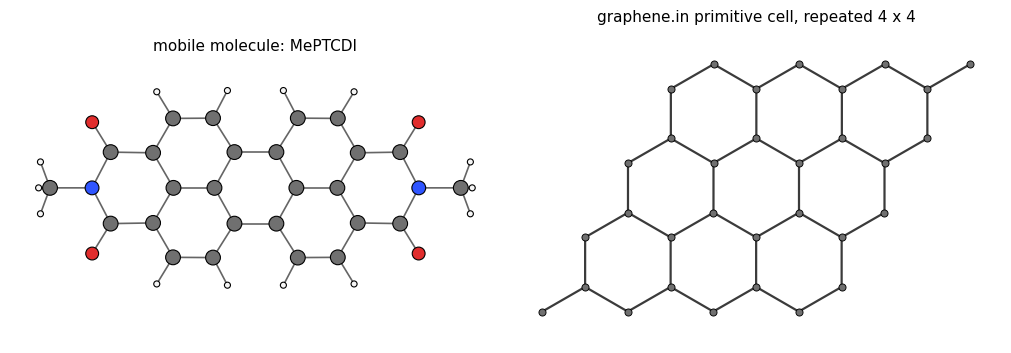

In [4]:
molecule = center_atoms_xy(read(SETUP / 'MePTCDI.in', format='aims'))
graphene_frame = center_atoms_xy(read(SETUP / 'graphene.in', format='aims').repeat((4, 4, 1)))
fig, axes = plt.subplots(1, 2, figsize=(10, 4.8), constrained_layout=True)
plot_ball_and_stick(axes[0], molecule, 'mobile molecule: MePTCDI', view='top', radius_scale=0.34)
plot_graphene_patch(axes[1], graphene_frame, 'graphene.in primitive cell, repeated 4 x 4')
fig.savefig(ASSETS / 'tutorial-structures.png', dpi=220, bbox_inches='tight')


## 2. Generate candidate structures

Generation is where GenSec creates trial placements of the molecule on the fixed frame. A generated structure is not automatically accepted. GenSec samples a trial configuration, checks whether it satisfies the geometric and optional force criteria, and only then writes it to the generated-structure databases.

The basic generation budget is controlled by the top-level `trials` and `success` values:

```json
{
  "trials": 5000,
  "success": 2000,
  "number_of_replicas": 1
}
```

`success` is the target number of accepted structures. `trials` is the maximum number of attempts allowed to reach that target. This distinction is important: if many sampled configurations clash, fail the supercell construction, duplicate an existing structure, or fail the force check, the number of trials can be much larger than the number of successful structures. `number_of_replicas` controls how many copies of the moving molecule are generated in the frame; here it is one MePTCDI molecule on graphene.

The protocol block says that this part of the run is generation, not search, and that configurations are sampled randomly:

```json
{
  "protocol": {
    "generate": {
      "activate": true,
      "method": "random"
    },
    "search": {
      "activate": false,
      "method": "random",
      "folder": "temp"
    },
    "check_db": false
  }
}
```

Because the fixed frame is a periodic unit cell, GenSec also has to decide which combined molecule/frame supercell should be used for each generated configuration. In molecule-on-surface problems this matters: the molecule and the substrate have different natural cells, and the code needs a commensurate cell that can contain both without bad overlaps or unrealistic strain.

This example enables the supercell finder:

```json
{
  "supercell_finder": {
    "activate": true,
    "unit_cell_method": "find",
    "max_attempts": 20,
    "m_range": {
      "type": "given_range",
      "max_s": 15,
      "max_f": 5,
      "max_range_s": [12, 12],
      "max_range_f": [1, 1]
    },
    "max_atoms": 110,
    "max_area_diff": 0.1,
    "z_cell_length": 100
  }
}
```

`unit_cell_method: "find"` means the molecule orientation is first used to infer a molecular unit cell, and then GenSec searches for a compatible supercell between that molecular cell and the graphene cell. `max_attempts` limits how many candidate commensurate cells are tried. `max_area_diff` controls how close the two supercell areas must be. `max_atoms` is a practical cutoff: it prevents generation from accepting cells that become too large.

That size limit is not just cosmetic. Every accepted generated structure can later become a candidate for DFT labeling, and DFT labeling is the expensive part of the workflow. Keeping generation cells reasonably small makes the later labeled database affordable. For this example, the goal is to demonstrate the workflow on manageable structures, not to generate a huge graphene patch around every molecule.

The molecular cell used by the supercell finder is controlled by `unit_cell_finder`:

```json
{
  "unit_cell_finder": {
    "min_angle": 20,
    "max_angle": 90,
    "seperation_factor": 1.0,
    "scan_first": {
      "activate": false,
      "first_min_angle": 0,
      "first_max_angle": 180,
      "first_n_steps": 10
    },
    "adaptive": {
      "activate": false
    }
  }
}
```

Here the finder is allowed to look for molecular cell angles between 20 and 90 degrees. The scan/adaptive refinements are off in this example, so the setup stays simple.

The molecular degrees of freedom are then controlled by the `configuration` block. For this example the molecule is internally rigid, because torsions are off, but it can rotate and move above the graphene frame:

```json
{
  "configuration": {
    "torsions": {
      "activate": false,
      "known": false,
      "same": false,
      "list_of_tosrions": "auto",
      "values": "random"
    },
    "orientations": {
      "activate": true,
      "same": true,
      "values": "random"
    },
    "coms": {
      "activate": true,
      "z_values": "identical",
      "values": "restricted",
      "x_axis": [0, 0, 1],
      "y_axis": [0, 0, 1],
      "z_axis": [3, 6, 19]
    }
  }
}
```

The important physical choice here is the center-of-mass region. The `z_axis` range asks GenSec to place the molecule above graphene, here between 3 and 6 A, instead of anywhere in space. The x/y region is deliberately small for the example, so the generated database stays manageable.

A trial structure must pass several checks before it becomes a success. First, the geometry-level clash checks avoid obvious overlaps:

```json
{
  "clashes": {
    "intramolecular": 2.0,
    "with_fixed_frame": 2.0
  }
}
```

For this example, GenSec also checks whether the proposed structure is already present in the generated, relaxed, or trajectory databases. That avoids spending later steps on duplicate configurations. If the supercell finder is active, the candidate cell also has to pass the supercell construction and `max_atoms` limit before it is written.

Second, this example uses a cheap force check during generation:

```json
{
  "check_forces": {
    "activate": true,
    "max_force": 10,
    "max_time": 20
  }
}
```

At this point GenSec needs a calculator only as a quick filter. The purpose is to ask: is this generated structure obviously terrible, for example because the forces are huge? For that reason, the calculator used here should usually be cheap. It can be a foundation MACE model, a previously trained model, or any other ASE calculator that is fast enough to call during generation.

This calculator is defined in the top-level `calculator` block below. It is different from the reference calculator used later for training labels. In this example, the generation force check uses `supporting/ase_command.py`; later, labeling uses `supporting/aims_command.py`.

```json
{
  "calculator": {
    "supporting_files_folder": "supporting",
    "ase_parameters_file": "ase_command.py",
    "algorithm": "FIRE",
    "optimize": "generate",
    "steps": 20,
    "fmax": 0.005,
    "constraints": {
      "fix_atoms": [-10, -9]
    }
  }
}
```

The figure below uses `setup/good_luck.xyz`, one accepted generated structure, only to show what a successful placement looks like from the side.




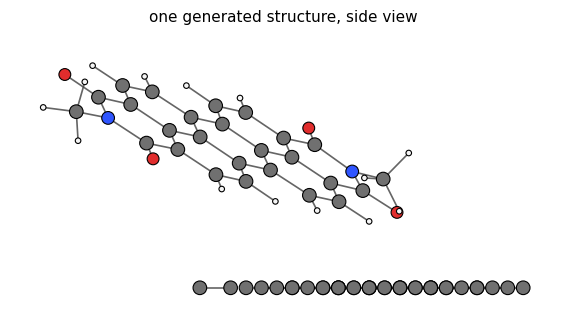

In [4]:
setup_parameters = json.loads((SETUP / 'parameters.json').read_text(encoding='utf-8'))

generated_example = center_atoms_xy(read(SETUP / 'good_luck.xyz'))
fig, ax = plt.subplots(1, 1, figsize=(7.5, 3.2), constrained_layout=True)
plot_ball_and_stick(ax, generated_example, 'one generated structure, side view', view='side', radius_scale=0.27)
fig.savefig(ASSETS / 'tutorial-generated-side-view.png', dpi=220, bbox_inches='tight')




### Files written by generation

When a trial structure is accepted, GenSec writes it to ASE databases in the run folder. The important generation outputs are:

```text
db_generated.db
db_generated_visual.db
db_generated_frames.db
good_luck.xyz
bad_luck.xyz
```

`db_generated.db` stores the generated moving structure in the form used internally by GenSec. For this example, that is the molecular part after the accepted configuration has been created.

`db_generated_visual.db` is the most useful database as it stores the combined structure, molecule plus fixed frame. This is usually the most convenient database to inspect visually, and it is also the default input used by FPS in this example.

`db_generated_frames.db` is written when the fixed frame comes from a unit cell and the supercell finder is active. It stores the frame corresponding to each accepted generated configuration, which matters because different accepted configurations can produce different compatible supercells.

`good_luck.xyz` is overwritten with the last accepted combined structure. It is useful as a quick visual check that generation is producing reasonable placements. `bad_luck.xyz`, when present, is the analogous quick-look file for a rejected or problematic candidate.

In the completed example, the same kind of files can be inspected in `final/`. The FPS step in the next section reads the generated visual database and writes a selected or ordered database called `db_generated_fps.db`.




## 3. Select structures with FPS

After generation, many candidate structures can be very similar. 

FPS, farthest-point sampling, either orders or selects structures so that the resulting set covers the generated pool more evenly or in the most "diverse" order possible. The example activates FPS with:

```json
{
  "fps_selection": {
    "activate": true,
    "n_select": "all"
  }
}
```

Here `n_select: "all"` means that the full generated pool is kept, but in FPS order. This is useful for training loops: each round can take the next diverse batch instead of just taking structures in database order.




## 4. MLIP training: label with the reference calculator

Once a database of sensible quasi-random candidate structures has been generated, one could in principle proceed with a search/minimization step directly. At an accurate electronic-structure level, however, relaxing or searching many molecule-on-frame structures is computationally demanding. In this workflow, the generated database is instead used as the starting pool for training a system-specific MACE machine-learning interatomic potential. The training set is built iteratively from the FPS-ordered generated structures until the RMSE targets are reached or the pool is exhausted.

Labeling means computing reference energies and forces for selected generated structures. In this example the reference method is FHI-aims, called through ASE. The reference calculator for training is set inside the `training` block:

```json
{
  "training": {
    "supporting_files_folder": "supporting",
    "ase_parameters_file": "aims_command.py",
    "k_density": 30.0
  }
}
```

The file is therefore `setup/supporting/aims_command.py`. This is where the level of theory is chosen: the example uses PBE, FHI-aims light species defaults, scalar atomic ZORA, no spin polarization, and force calculation enabled. The training pipeline computes a suitable `k_grid` for each structure from `training.k_density`.

A separate pre-processing step has to be performed by the user for the isolated atoms. To train the model, MACE strongly benefits from isolated-atom reference energies, `E0s`. These values must be computed consistently with the same reference setup used for labeling: same code, same species defaults, same exchange-correlation functional, same relativistic treatment, and the same general numerical choices where applicable.

This system contains H, C, N, and O, so the input contains one atomic energy for each atomic number:

```json
{
  "mace_args": {
    "E0s": {
      "1": -13.5980301782,
      "6": -1029.1067769881,
      "7": -1485.3076478427,
      "8": -2043.2399676739
    }
  }
}
```

The isolated-atom calculation folders are in `atoms/`. In this notebook we only inspect the prepared files; for a real run, the atom calculations and the structure-labeling jobs are submitted from the run folders or on the cluster.




In [5]:
if 'setup_parameters' not in globals():
    setup_parameters = json.loads((SETUP / 'parameters.json').read_text(encoding='utf-8'))

e0s = setup_parameters['training']['mace_args']['E0s']
print('Atomic reference energies used in parameters.json:')
for atomic_number, energy in e0s.items():
    print(f'  Z={atomic_number}: {energy:.10f} eV')

print('\nReference level of theory from setup/supporting/aims_command.py:')
aims_command_text = (SETUP / 'supporting' / 'aims_command.py').read_text(encoding='utf-8')
interesting_settings = []
for line in aims_command_text.splitlines():
    stripped = line.strip().rstrip(',')
    if stripped.startswith(('xc=', 'spin=', 'relativistic=', 'compute_forces=', 'sc_iter_limit=')):
        interesting_settings.append(stripped)
for setting in interesting_settings:
    print(f'  {setting}')
print(f"  k_density={setup_parameters['training']['k_density']}  # converted to k_grid per structure by the training pipeline")




Atomic reference energies used in parameters.json:
  Z=1: -13.5980301782 eV
  Z=6: -1029.1067769881 eV
  Z=7: -1485.3076478427 eV
  Z=8: -2043.2399676739 eV

Reference level of theory from setup/supporting/aims_command.py:
  xc='pbe'
  spin='none'
  relativistic='atomic_zora scalar'
  compute_forces=True
  sc_iter_limit=100
  k_density=30.0  # converted to k_grid per structure by the training pipeline


## 5. Train MACE in rounds

At this point we have an FPS-ordered pool of generated structures. The training code uses that pool to build a labeled dataset gradually. The idea is to avoid labeling everything at once: label a batch, train a model, check the error, then decide whether another batch is needed.

The main training switches in this example are:

```json
{
  "training": {
    "activate": true,
    "loop_activate": true,
    "phase2_activate": true,
    "supporting_files_folder": "supporting",
    "ase_parameters_file": "aims_command.py",
    "test_set_size": 30,
    "mace_output_name": "MeC",
    "rmse_energy_target": 1.0,
    "rmse_force_target": 40.0,
    "state_file": "training_state.json",
    "global_labeled_db": "db_labeled_global.db"
  }
}
```

The important choices are:

- `loop_activate: true`: use iterative training, not one-shot training.
- `ase_parameters_file: "aims_command.py"`: use the FHI-aims reference calculator for labels.
- `test_set_size: 30`: keep 30 structures aside before training starts.
- `rmse_energy_target` and `rmse_force_target`: stop when both test errors are low enough.
- `state_file`: keep a checkpoint so the loop can resume.

### First: make a fixed test set

Before any training batch is labeled, the code creates the test set. This is done first so every model round is evaluated on the same structures.

If the source database already contains force information, the code tries to select test structures from dividing them into force bins and sampling equally from them, sucht that the test set contains both easier and harder case structures (low and high forces).

This step writes:

```text
db_labeled_test.db
mace_dataset_test.extxyz
db_labeled_test_easy.db
mace_dataset_test_easy.extxyz
db_train_pool.db
```

`db_train_pool.db` is the FPS pool after removing the fixed test structures. Training batches are taken only from this pool, so the test structures are not used for training.

The `easy` test set is made from the same fixed test set by dropping the hardest force bins. It is not an independent dataset. It is a diagnostic view: if the full RMSE is bad but the easy RMSE is reasonable, a few very high-force structures may be dominating the error.

### Then: repeat training rounds

Once the test set exists, the loop starts taking batches from `db_train_pool.db`. The current code uses a simple built-in schedule:

```text
round 1: 60 structures
round 2: 50 structures
round 3: 40 structures
round 4: 30 structures
round 5: 25 structures
later rounds: 20 structures
```

Each round does the same sequence:

1. take the next FPS-ordered batch;
2. label it with `aims_command.py`;
3. append the new labels to `db_labeled_global.db`;
4. build the cumulative training database for that round;
5. export the cumulative database to MACE `.extxyz` files;
6. run `mace_run_train` in a new `training_round_XXX/` folder;
7. copy the newest model to `latest.model`;
8. evaluate the model on the fixed full and easy test sets;
9. save the metrics and next FPS index in `training_state.json`.

The cumulative part is important: round 2 trains on labels from rounds 1 and 2, round 3 trains on labels from rounds 1 to 3, and so on. The labeled database grows; the model is not trained only on the newest batch.

The MACE model settings are passed through `mace_args`:

```json
{
  "mace_args": {
    "r_max": 5.0,
    "hidden_irreps": "64x0e + 64x1o",
    "batch_size": 6,
    "valid_batch_size": 6,
    "max_num_epochs": 3000,
    "patience": 40
  }
}
```

These are MACE arguments, not special GenSec keywords. GenSec sets useful defaults, but values in `mace_args` override or extend what is passed to `mace_run_train`.

### What the RMSE means

After every round, GenSec evaluates the trained model itself on the labeled test databases:

- `full` RMSE: error on all structures in `db_labeled_test.db`;
- `easy` RMSE: error on `db_labeled_test_easy.db`, after removing the hardest force bins.

The loop stops when both convergence criteria are reached, here 1 meV/atom for energy and 40 meV/A for forces. If the FPS pool is exhausted first, the loop stops without convergence. Because `training_state.json` stores the current round, next FPS index, model path, and RMSE history, interrupted runs can continue without repeating completed labeling and training work.




### Restarting and tracking training progress

The training loop writes a checkpoint file, `training_state.json`, after each completed round. This file is important because labeling and training can take hours or days on a cluster. The state file tells GenSec where the loop stopped and which FPS structures should be used next.

The top of the completed example state file looks like this:

```json
{
  "next_fps_index": 270,
  "round_index": 14,
  "status": "exhausted"
}
```

`next_fps_index` is the next row position in the FPS-ordered training pool. In the completed example, 270 training structures had already been consumed. `round_index` is the next round the code would try to run. `status` tells whether the phase-1 loop is still running, converged, or exhausted.

Each finished round is stored in the `history` list. A single entry records which FPS slice was used, where the round folder is, which model was produced, and what the test errors were:

```json
{
  "round": 1,
  "fps_start_index": 0,
  "fps_count": 60,
  "test_rmse": {
    "energy_rmse_mev_per_atom": 8.608,
    "force_rmse_mev_per_a": 332.811
  },
  "easy_test_rmse": {
    "energy_rmse_mev_per_atom": 2.833,
    "force_rmse_mev_per_a": 64.445
  },
  "round_dir": ".../training_round_001",
  "phase1_model": ".../MeC_round001_stagetwo_compiled.model"
}
```

This is the file used to resume the loop. If `training_state.json` exists, GenSec reads `next_fps_index` and `round_index` instead of starting again from round 1.

The code also has several file-based restart capabilities. They are collected at the end of the notebook in [Restart capabilities reference](#10-restart-capabilities-reference).




training_state.json: status=exhausted, completed_rounds=13, next_fps_index=270, next_round=14

Round history:
round  fps_start  fps_count  full_E  full_F  easy_E  easy_F
    1          0         60   8.608   332.8   2.833    64.4
    2         60         40   4.347   260.7   2.238    44.0
    3        100         30   4.951   188.1   1.571    29.6
    4        130         25   4.436   187.9   0.962    26.5
    5        155         20   4.326   201.6   1.249    37.9
    6        175         15   5.452   203.1   0.908    27.1
    7        190         10   6.524   214.6   1.262    37.7
    8        200         10   3.214   243.8   1.260    39.3
    9        210         10   4.398   210.6   0.832    27.3
   10        220         10   3.628   193.4   0.652    28.2
   11        230         10   4.896   216.7   0.590    25.9
   12        240         20   4.674   195.6   0.610    26.2
   13        260         10   3.137   254.8   0.716    30.1


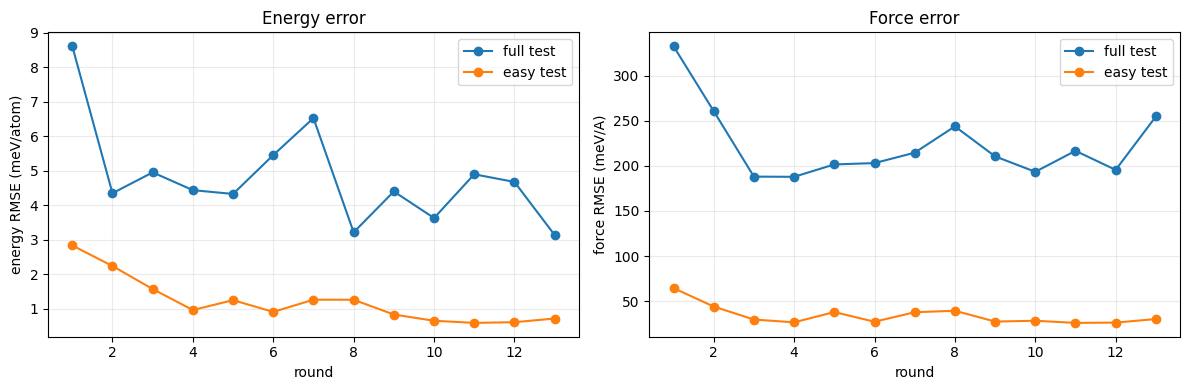

In [6]:
state = json.loads((FINAL / 'training_state.json').read_text(encoding='utf-8'))
history = state['history']

print(
    f"training_state.json: status={state.get('status')}, "
    f"completed_rounds={len(history)}, "
    f"next_fps_index={state.get('next_fps_index')}, "
    f"next_round={state.get('round_index')}"
)

print('\nRound history:')
print('round  fps_start  fps_count  full_E  full_F  easy_E  easy_F')
for row in history:
    print(
        f"{row['round']:>5}  "
        f"{row['fps_start_index']:>9}  "
        f"{row['fps_count']:>9}  "
        f"{row['test_rmse']['energy_rmse_mev_per_atom']:>6.3f}  "
        f"{row['test_rmse']['force_rmse_mev_per_a']:>6.1f}  "
        f"{row['easy_test_rmse']['energy_rmse_mev_per_atom']:>6.3f}  "
        f"{row['easy_test_rmse']['force_rmse_mev_per_a']:>6.1f}"
    )

rounds = [row['round'] for row in history]
full_energy = [row['test_rmse']['energy_rmse_mev_per_atom'] for row in history]
full_force = [row['test_rmse']['force_rmse_mev_per_a'] for row in history]
easy_energy = [row['easy_test_rmse']['energy_rmse_mev_per_atom'] for row in history]
easy_force = [row['easy_test_rmse']['force_rmse_mev_per_a'] for row in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rounds, full_energy, marker='o', label='full test')
axes[0].plot(rounds, easy_energy, marker='o', label='easy test')
axes[0].set(xlabel='round', ylabel='energy RMSE (meV/atom)', title='Energy error')
axes[1].plot(rounds, full_force, marker='o', label='full test')
axes[1].plot(rounds, easy_force, marker='o', label='easy test')
axes[1].set(xlabel='round', ylabel='force RMSE (meV/A)', title='Force error')
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
fig.tight_layout()




### Files written by training

The iterative training loop writes both global files in the run folder and per-round files in `training_rounds/` or `training_round_XXX/` folders. The important top-level training outputs are:

```text
db_labeled_test.db
db_labeled_test_easy.db
db_train_pool.db
db_labeled_global.db
mace_dataset_test.extxyz
mace_dataset_test_easy.extxyz
training_state.json
latest.model
```

`db_labeled_test.db` and `db_labeled_test_easy.db` are the fixed evaluation sets. `db_train_pool.db` is the FPS pool after removing the test structures. `db_labeled_global.db` is the cumulative labeled database, including the fixed test labels and the labels added during the rounds.

`mace_dataset_test.extxyz` and `mace_dataset_test_easy.extxyz` are the MACE-readable versions of the test databases. `training_state.json` tracks the loop progress, as described above. `latest.model` is the most convenient model path for later generation or search: after each successful round, GenSec copies the newest trained phase-1 model there.

Each training round also has its own folder. A typical round contains files like:

```text
training_round_001/
  fps_batch_round_001.db
  db_labeled_round_001.db
  db_labeled_cumulative_001.db
  mace_dataset_train.extxyz
  MeC_round001.model
  MeC_round001_compiled.model
  MeC_round001_stagetwo.model
  MeC_round001_stagetwo_compiled.model
  checkpoints/
```

The round database names describe the data flow. `fps_batch_round_001.db` is the selected unlabeled batch. `db_labeled_round_001.db` is the same batch after reference labeling. `db_labeled_cumulative_001.db` is the full training database used in that round. `mace_dataset_train.extxyz` is what is passed to MACE.

The MACE model files are produced by `mace_run_train`. In this example the most useful per-round artifact is usually the compiled stage-two model, for example `MeC_round001_stagetwo_compiled.model`. GenSec then keeps a copy of the newest selected model as `latest.model` at the run-folder level, so later parts of the workflow do not need to know which round produced it. If the phase-1 loop reaches the RMSE targets, the converged phase-1 model is also saved as `phase1.model`. If phase 2 is run successfully, the final augmented model is copied to `final.model` and `latest.model` is updated again.

The workflow does not have to be run as one monolithic job. The input file controls which stages are active:

```json
{
  "protocol": {
    "generate": {"activate": true},
    "search": {"activate": false}
  },
  "fps_selection": {
    "activate": true
  },
  "training": {
    "activate": true,
    "loop_activate": true,
    "phase2_activate": true
  }
}
```

With all of these active, generation, FPS, and training can be launched from the same run. During development or on a cluster, it is often cleaner to split the workflow: run generation first, then FPS, then training, then search with the trained model. Because the code reads and writes explicit database/model files, later stages can reuse files produced by earlier stages instead of recomputing everything.




## 6. Add phase 2 training after the loop

Phase 2 is a final extra-step in the training, and is enabled in the same training block:

```json
{
  "training": {
    "loop_activate": true,
    "phase2_activate": true
  }
}
```

Phase 2 only makes sense after loop training, because it needs a phase-1 model. The code uses that model to cheaply relax or score the remaining generated structures, keeps low-energy candidates, applies diversity selection again, labels that selected subset with the reference calculator, and trains a final augmented model.

Conceptually: phase 1 learns from diverse generated structures; phase 2 uses the learned potential to focus additional labeling on structures that look more relevant for low-energy search.




## 7. Search or generate with the trained model

After training, the calculator used for generation/search can point to the newly trained MACE model. In practice, we suggest doing this in a separate clean run folder. 

This is also where the physical scope can change. During training, we kept the generated structures reasonably small because every selected structure could become a DFT label, and DFT labelling is expensive. Once a good enough system-specific MLIP exists, that restriction can and should be lifted to better explore the conformational space of the molecule on the fixed frame. A natural next step is to run a new GenSec generation/search with larger graphene cells, more candidate structures, or a broader sampling region, and use the trained model to relax them cheaply.

For this tutorial we do not launch a larger generation phase. Instead, we include a lightweight search folder that reuses the existing generated database and shows how the trained-model calculator is wired in.

This tutorial includes an example search folder:

```text
tutorial/search/
```

That folder is a search-only setup. It contains the molecule and frame files, a generated-structure database to relax, `latest.model` from the previous training, and a calculator script that loads the trained model. The important input choices are:

```json
{
  "protocol": {
    "generate": {"activate": false},
    "search": {
      "activate": true,
      "method": "random",
      "folder": "search_relaxations"
    },
    "check_db": true
  },
  "fps_selection": {
    "activate": false
  },
  "training": {
    "activate": false,
    "loop_activate": false,
    "phase2_activate": false
  },
  "calculator": {
    "supporting_files_folder": "supporting",
    "ase_parameters_file": "trained_model_command.py",
    "algorithm": "FIRE",
    "optimize": "generate",
    "steps": 200,
    "fmax": 0.02
  }
}
```

The important change is the calculator. During the original generation step, the input used a cheap screening calculator:

```json
{
  "calculator": {
    "ase_parameters_file": "ase_command.py"
  }
}
```

For the trained-model search, the same calculator role is now filled by:

```json
{
  "calculator": {
    "ase_parameters_file": "trained_model_command.py"
  }
}
```

`trained_model_command.py` loads `latest.model` from the search folder by default. If you want to use a different model path, set `GENSEC_MACE_MODEL` before launching GenSec.

Search mode reads the existing `db_generated_visual.db`, relaxes structures with the trained model, and writes the results to `db_relaxed.db`, `db_trajectories.db`, and the `search_relaxations/` folder. Conceptually this can be either a GenSec continuation, where you first generated the structures with GenSec, or a cleaner Sec-style run, where the trained potential is used only to relax/search an already prepared candidate pool.

The separation is important: `training.ase_parameters_file` is the expensive reference calculator used to create labels, while top-level `calculator.ase_parameters_file` is the calculator used for generation checks and search.


## 9. Edit the input with the GUI

The GUI is a practical way to edit `parameters.json` without remembering every nested key. For this example, the important pages are the system definition, generation/configuration, FPS, calculator, and training/MACE sections.

The screenshots show where those choices appear in the interface.




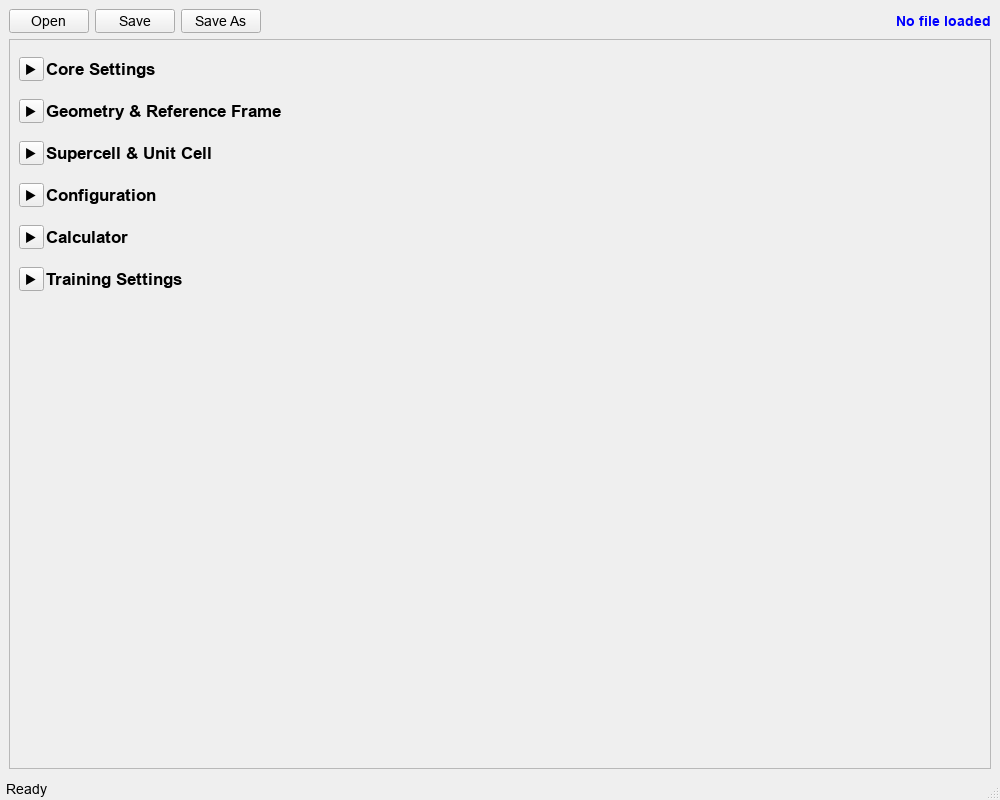

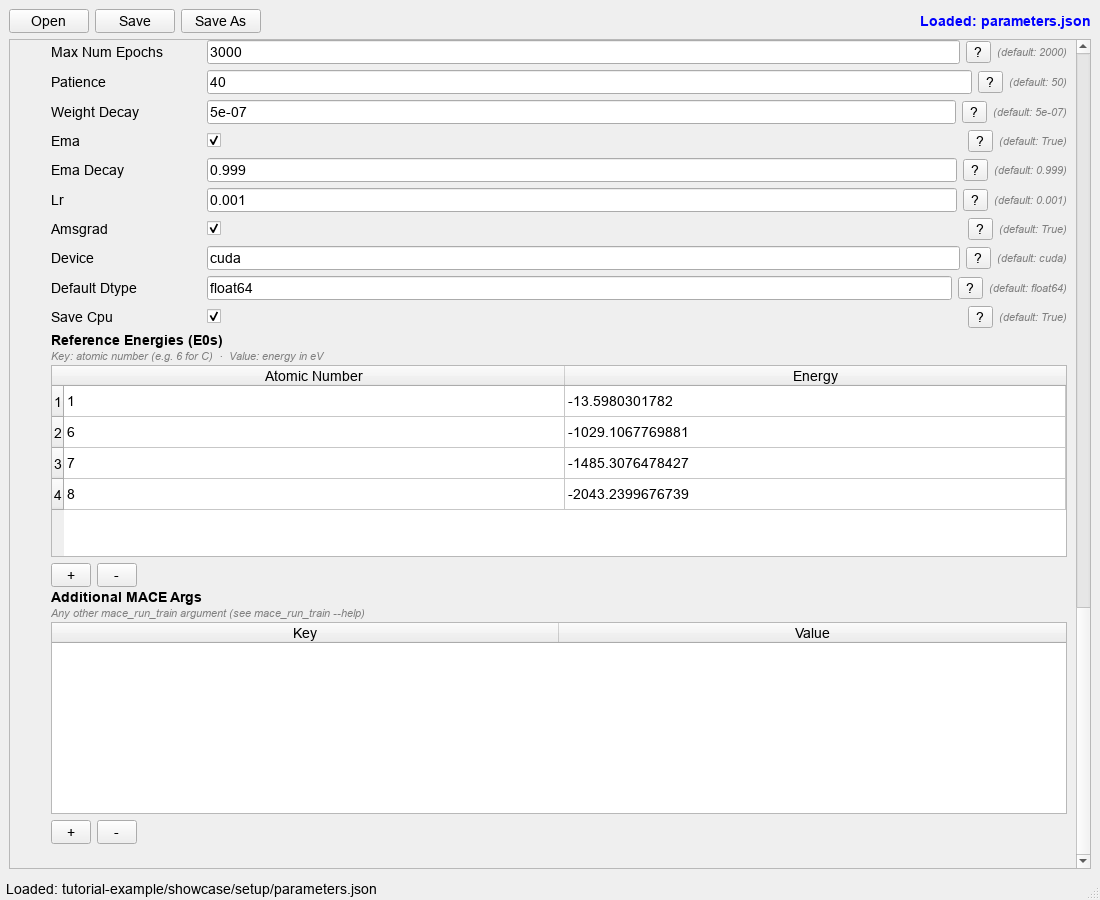

In [7]:
try:
    from IPython.display import Image, display
except ImportError:
    print('Open the PNG files in tutorial/assets directly.')
else:
    display(Image(filename=str(ASSETS / 'gui-overview.png')))
    display(Image(filename=str(ASSETS / 'gui-training.png')))




## 10. Restart capabilities reference

GenSec tries to avoid repeating expensive work when the expected intermediate files are already present. The restart behavior is deliberately file-based:

- If the fixed test set already exists as `db_labeled_test.db`, GenSec reuses it instead of selecting and labeling a new test set.
- If the test `.extxyz` file is missing but the labeled test DB exists, the `.extxyz` file is rebuilt from the DB.
- If `db_train_pool.db` is missing but the existing test DB has `source_row_id` metadata, the train pool is rebuilt by removing the test rows from the source DB.
- If a round already has a non-empty `db_labeled_cumulative_XXX.db`, GenSec treats that round as already labeled and does not repeat the reference labeling for that cumulative data.
- If the round training `.extxyz` file is missing, it is rebuilt from `db_labeled_cumulative_XXX.db`.
- If `training_state.json` says `status: "converged"`, the phase-1 loop is skipped.
- If labels were prepared outside the loop, `loop_use_external_labeled_db` can make the loop reuse an external labeled DB instead of calling the reference calculator inside each round.
- In one-shot mode, `do_labeling: false` lets the code reuse an existing labeled DB, and `do_training: false` lets it stop after preparing the dataset.
- For phase 2, if the state records `phase2.status: "completed"`, the phase-2 refinement is skipped on restart.

There is one practical limitation: if a round finished MACE training but stopped before `training_state.json` was updated, the code may rerun the MACE command for that round. The expensive reference labeling is still protected by the existing labeled/cumulative databases, but the state file is what marks the round as fully completed.




## 11. Adapting the example

For a new molecule-on-frame system, the main changes are the physical ones:

- replace `MePTCDI.in` with your molecule;
- replace `graphene.in` with your fixed frame, or set `fixed_frame.activate = false` for a molecule-only problem;
- choose the generation region, especially the allowed COM height above the frame;
- decide whether the molecule should rotate, change torsions, or stay rigid;
- choose the cheap calculator for generation force checks/search;
- choose the reference calculator for labels;
- recompute `E0s` for every element in the system;
- choose how many generated structures to label each training round.

The code can also resume from existing generated, FPS, labeled, or training files, so a run does not have to be repeated from zero every time. This example keeps the path simple, but the same machinery is meant for interrupted cluster jobs and staged calculations.


